In [1]:
import pandas as pd
import numpy as np
from understatapi import UnderstatClient

In [2]:
TEAM_NAME = "Tottenham"
SEASONS = ["2022", "2023", "2024", "2025"]

In [3]:
all_matches = []

with UnderstatClient() as understat:
    for season in SEASONS:

        try:
            context_data = understat.team(team=TEAM_NAME).get_context_data(season=season)
            
            timing_dict = context_data.get("timing", {})

            # 順番を制御する＆扱いやすくするため
            interval_mapping = {
                "1-15": 1,
                "16-30": 2,
                "31-45": 3,
                "46-60": 4,
                "61-75": 5,
                "76+": 6
            }
            
            
            for time_interval, stats in timing_dict.items():
                row= {
                    "season": season,
                    "team": TEAM_NAME,
                    "interval": time_interval,
                    "interval_order": interval_mapping.get(time_interval, 99),
                    "shots": int(stats.get("shots", 0)),
                    "goals": int(stats.get("goals", 0)),
                    "xG": float(stats.get("xG", 0.0)),
                    "shots_against": int(stats.get("against", {}).get("shots", 0)),
                    "goals_against": int(stats.get("against", {}).get("goals", 0)),
                    "xGA": float(stats.get("against", {}).get("xG", 0.0))
                    
                }
    
                all_matches.append(row)

        except Exception as e:
            print(f"Error fetching data for season {season}: {e}")

df_raw = pd.DataFrame(all_matches)

In [5]:
df = df_raw.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          24 non-null     str    
 1   team            24 non-null     str    
 2   interval        24 non-null     str    
 3   interval_order  24 non-null     int64  
 4   shots           24 non-null     int64  
 5   goals           24 non-null     int64  
 6   xG              24 non-null     float64
 7   shots_against   24 non-null     int64  
 8   goals_against   24 non-null     int64  
 9   xGA             24 non-null     float64
dtypes: float64(2), int64(5), str(3)
memory usage: 2.0 KB


In [6]:
df_summary = df_raw.groupby(["season", "interval"])[["shots", "goals", "xG", "shots_against", "goals_against", "xGA"]].sum().reset_index()

In [7]:
df_summary["season_total_conceded"] = df_summary.groupby("season")["goals_against"].transform("sum")

In [8]:
# 失点割合（％）を出す
df_summary["conceded_percentage"] = df_summary["goals_against"] / df_summary["season_total_conceded"] * 100
# 小数点第一位で丸める（四捨五入）
df_summary["conceded_percentage"] = df_summary["conceded_percentage"].round(1)
df_summary[["season", "interval", "goals_against", "season_total_conceded", "conceded_percentage"]]

,season,interval,goals_against,season_total_conceded,conceded_percentage
0,2022,1-15,14,63,22.2
1,2022,16-30,8,63,12.7
2,2022,31-45,9,63,14.3
3,2022,46-60,11,63,17.5
4,2022,61-75,9,63,14.3
5,2022,76+,12,63,19.0
6,2023,1-15,8,61,13.1
7,2023,16-30,12,61,19.7
8,2023,31-45,8,61,13.1
9,2023,46-60,12,61,19.7


In [11]:
# 均等に失点した場合の基準値（100％ ÷ 6グループ ≒ 16.67%）
base_percentage = 100 / 6
# 基準値からのズレを計算する
df_summary["conceded_deviation"] = df_summary["conceded_percentage"] - base_percentage
df_summary["conceded_deviation"] = df_summary["conceded_deviation"].round(1)

print("--- 基準（16.7％）からのズレを算出 ---")
df_summary[["season", "interval", "goals_against", "conceded_percentage", "conceded_deviation"]]

--- 基準（16.7％）からのズレを算出 ---


,season,interval,goals_against,conceded_percentage,conceded_deviation
0,2022,1-15,14,22.2,5.5
1,2022,16-30,8,12.7,-4.0
2,2022,31-45,9,14.3,-2.4
3,2022,46-60,11,17.5,0.8
4,2022,61-75,9,14.3,-2.4
5,2022,76+,12,19.0,2.3
6,2023,1-15,8,13.1,-3.6
7,2023,16-30,12,19.7,3.0
8,2023,31-45,8,13.1,-3.6
9,2023,46-60,12,19.7,3.0


In [12]:
import matplotlib.pyplot as plt

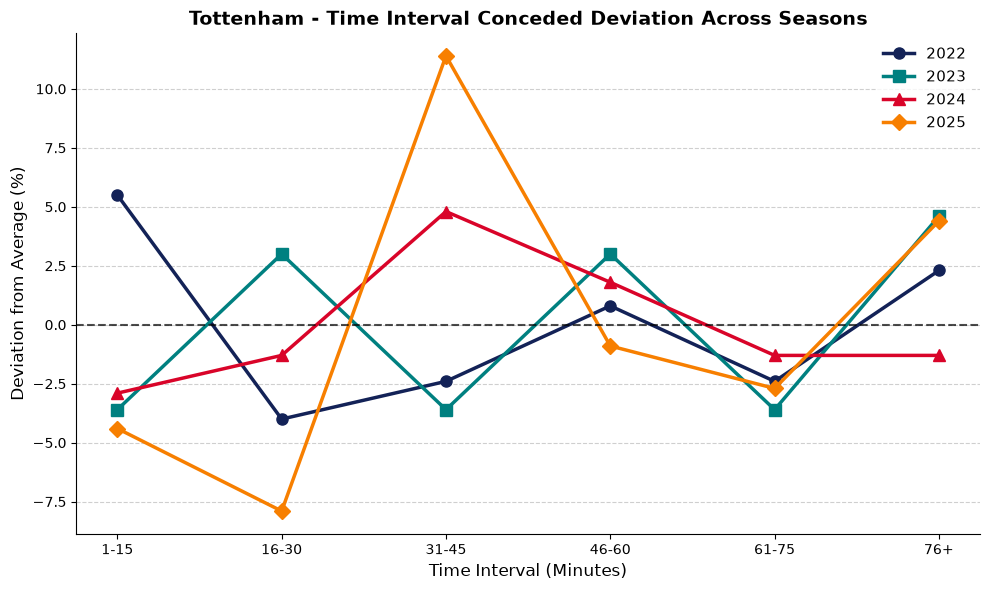

In [35]:
plt.figure(figsize=(10, 6))

colors = ["#132257", "#008080", "#D90429", "#F77F00"]
markers = ["o", "s", "^", "D"]

for i, season in enumerate(SEASONS):
    season_data = df_summary[df_summary["season"] == season]

    plt.plot(
        season_data["interval"],
        season_data["conceded_deviation"],
        marker=markers[i % len(markers)],
        color=colors[i % len(colors)],
        linewidth=2.5,
        markersize=8,
        label= season
    )

plt.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

plt.title(f"{TEAM_NAME} - Time Interval Conceded Deviation Across Seasons", fontsize=14, fontweight="bold")
plt.xlabel("Time Interval (Minutes)", fontsize=12)
plt.ylabel("Deviation from Average (%)", fontsize=12)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=11)

plt.tight_layout()
plt.show()

In [34]:
df.head(6)

,season,team,interval,interval_order,shots,goals,xG,shots_against,goals_against,xGA
0,2022,Tottenham,1-15,1,69,8,7.638104,81,14,10.373608
1,2022,Tottenham,16-30,2,73,7,7.365678,82,8,5.699483
2,2022,Tottenham,31-45,3,66,9,7.997466,90,9,9.709004
3,2022,Tottenham,46-60,4,117,13,14.285550,103,11,10.835323
4,2022,Tottenham,61-75,5,91,17,11.876871,82,9,7.459653
5,2022,Tottenham,76+,6,106,16,11.273399,82,12,8.949331


In [55]:
#実際の失点からxGAを引き算した「ミス・集中力キレの指標」
df_summary["xGA_diff"] = df_summary["goals_against"] - df_summary["xGA"]
df_summary["xGA_diff"] = df_summary["xGA_diff"].round(2)

df_summary[(df_summary["interval"] == "31-45") | (df_summary["interval"] == "76+")][["season", "interval", "xGA_diff"]]

,season,interval,xGA_diff
2,2022,31-45,-0.71
5,2022,76+,3.05
8,2023,31-45,-2.86
11,2023,76+,-1.46
14,2024,31-45,-1.34
17,2024,76+,0.01
20,2025,31-45,5.70
23,2025,76+,-0.63


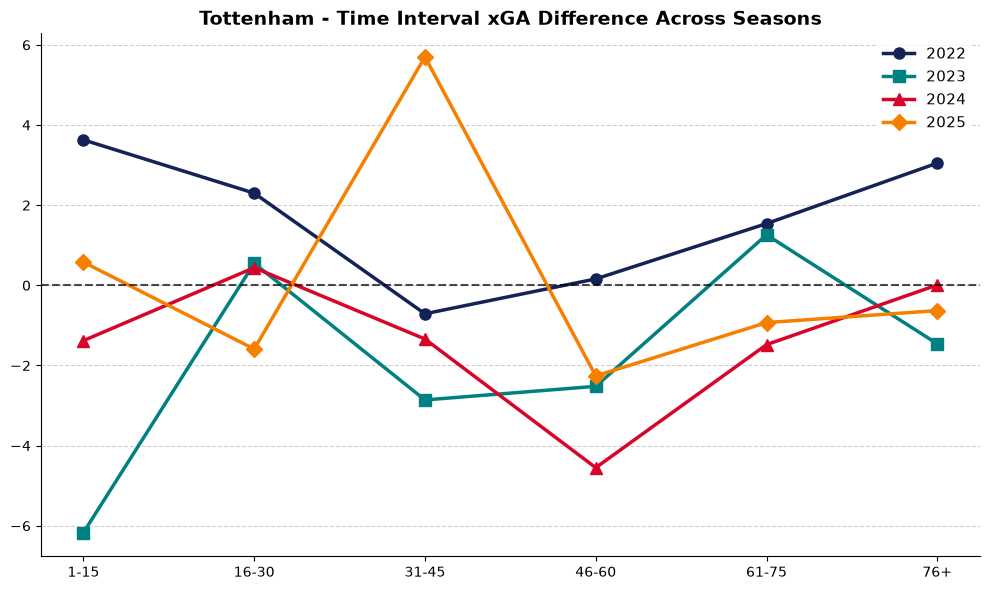

In [60]:
plt.figure(figsize=(10, 6))

colors = ["#132257", "#008080", "#D90429", "#F77F00"]
markers = ["o", "s", "^", "D"]

for i, season in enumerate(SEASONS):
    season_data = df_summary[df_summary["season"] == season]

    plt.plot(
        season_data["interval"],
        season_data["xGA_diff"],
        marker=markers[i % len(markers)],
        color=colors[i % len(colors)],
        linewidth=2.5,
        markersize=8,
        label= season
    )

plt.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

plt.title(f"{TEAM_NAME} - Time Interval xGA Difference Across Seasons", fontsize=14, fontweight="bold")
#plt.xlabel("Time Interval (Minutes)", fontsize=12)
#plt.ylabel("Deviation from Average (%)", fontsize=12)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=11)

plt.tight_layout()
plt.show()

In [66]:
df_summary["xG_diff"] = df_summary["goals"] - df_summary["xG"]
df_summary["xG_diff"] = df_summary["xG_diff"].round(2)

In [67]:
seasons = df_summary["season"]
xg_diff = df_summary["xG_diff"]
xga_diff = df_summary["xGA_diff"]

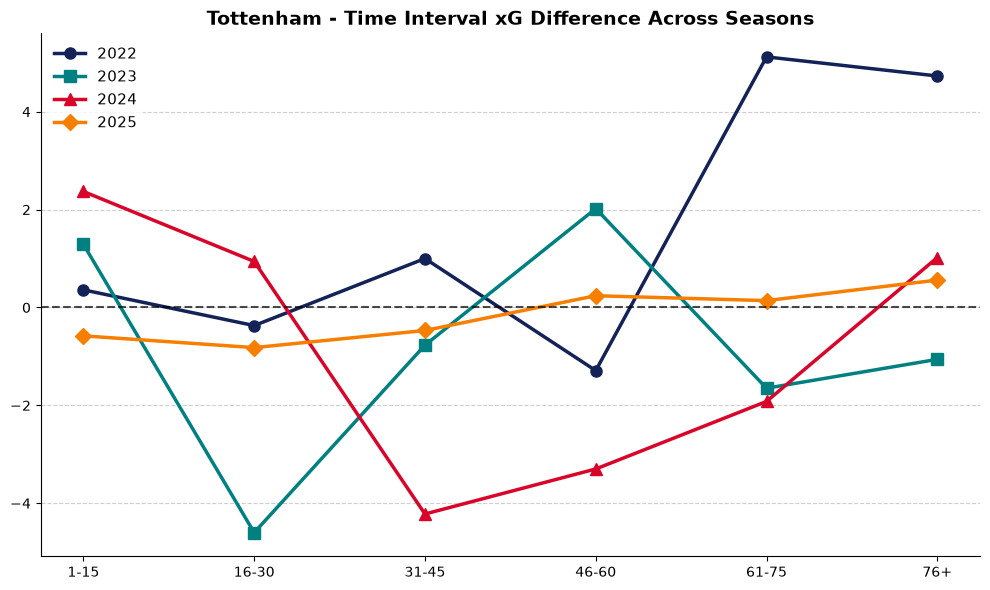

In [68]:
plt.figure(figsize=(10, 6))

colors = ["#132257", "#008080", "#D90429", "#F77F00"]
markers = ["o", "s", "^", "D"]

for i, season in enumerate(SEASONS):
    season_data = df_summary[df_summary["season"] == season]

    plt.plot(
        season_data["interval"],
        season_data["xG_diff"],
        marker=markers[i % len(markers)],
        color=colors[i % len(colors)],
        linewidth=2.5,
        markersize=8,
        label= season
    )

plt.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

plt.title(f"{TEAM_NAME} - Time Interval xG Difference Across Seasons", fontsize=14, fontweight="bold")
#plt.xlabel("Time Interval (Minutes)", fontsize=12)
#plt.ylabel("Deviation from Average (%)", fontsize=12)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=11)

plt.tight_layout()
plt.show()

In [34]:
match_states = []

with UnderstatClient() as understat:
    for season in SEASONS:
        try:
            context_data = understat.team(team=TEAM_NAME).get_context_data(season=season)
            state_dict = context_data.get("gameState", {})
    
            for goal_diff, stats in state_dict.items():
                row = {
                    "season": season,
                    "goal_diff": goal_diff,
                    "time": stats.get("time"),
                    "shots": stats.get("shots"),
                    "goals": stats.get("goals"),
                    "xG": stats.get("xG"),
                    "shots_against": stats.get("against").get("shots"),
                    "goals_against": stats.get("against").get("goals"),
                    "xGA": stats.get("against").get("xG")
                }
                match_states.append(row)
        except Exception as e:
            print(f"Error fetching data for season {season}: {e}")

match_raw = pd.DataFrame(match_states)

In [35]:
match_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   season         20 non-null     str    
 1   goal_diff      20 non-null     str    
 2   time           20 non-null     int64  
 3   shots          20 non-null     int64  
 4   goals          20 non-null     int64  
 5   xG             20 non-null     float64
 6   shots_against  20 non-null     int64  
 7   goals_against  20 non-null     int64  
 8   xGA            20 non-null     float64
dtypes: float64(2), int64(5), str(2)
memory usage: 1.5 KB


In [36]:
match_raw

,season,goal_diff,time,shots,goals,xG,shots_against,goals_against,xGA
0,2022,Goal diff 0,1541,215,28,23.624071,207,27,20.919183
1,2022,Goal diff +1,822,108,13,14.060679,119,10,8.152824
2,2022,Goal diff -1,632,97,13,12.398329,79,15,12.411409
3,2022,Goal diff < -1,395,66,9,6.234513,64,6,7.140909
4,2022,Goal diff > +1,226,36,7,4.119477,51,5,4.402077
5,2023,Goal diff 0,1678,246,31,31.562179,197,27,32.507935
6,2023,Goal diff +1,778,99,14,14.665255,115,11,15.130763
7,2023,Goal diff -1,523,108,15,15.216742,62,8,9.818866
8,2023,Goal diff > +1,414,72,8,9.635498,69,6,6.465000
9,2023,Goal diff < -1,309,62,6,7.677822,47,9,8.274268


In [38]:
match_raw.groupby(["goal_diff"]).sum()

,season,time,shots,goals,xG,shots_against,goals_against,xGA
goal_diff,,,,,,,,
Goal diff +1,2022202320242025,2644,336,47,49.773655,391,42,41.521109
Goal diff -1,2022202320242025,2834,451,46,53.131274,377,50,56.832799
Goal diff 0,2022202320242025,6428,818,101,97.131230,811,111,105.722287
Goal diff < -1,2022202320242025,1432,241,33,28.197304,212,27,31.496555
Goal diff > +1,2022202320242025,1318,198,29,29.006690,210,16,19.079010
